In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORT_IMAGES_DIR = PROJECT_ROOT / "report" / "images"
REPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
DATASETS = ("Set5", "Set14", "B100", "Urban100", "Manga109")
SCALES = (2, 3, 4)

with (OUTPUTS_DIR / "full_experiment_summary.json").open(encoding="utf-8") as handle:
    summary = json.load(handle)


def metrics(scale, stage, dataset):
    return summary["scales"][f"x{scale}"][stage]["evaluation"]["datasets"][dataset]


print(f'Loaded results for scales: {summary["protocol"]["scales"]}')
print(f"Figures will be saved to: {REPORT_IMAGES_DIR}")

Loaded results for scales: [2, 3, 4]
Figures will be saved to: /Users/morteza/w/univercity/MLInVision/Project/report/images


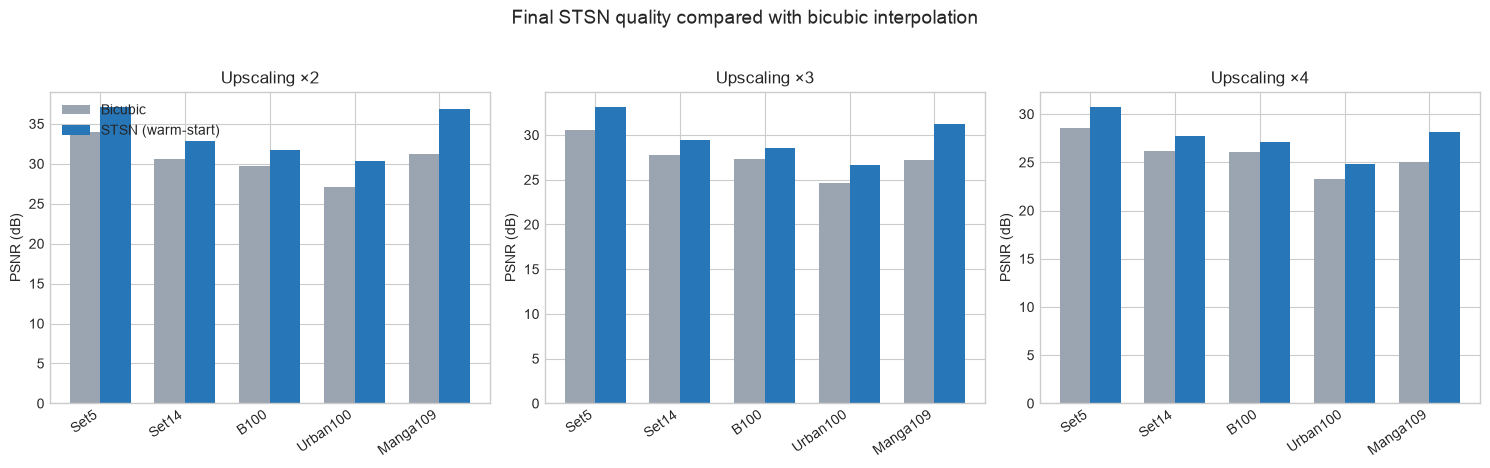

Saved report/images/benchmark_psnr_vs_bicubic.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
x = np.arange(len(DATASETS))
width = 0.36

for ax, scale in zip(axes, SCALES):
    stsn = [
        metrics(scale, "warm_start", dataset)["stsn"]["psnr"] for dataset in DATASETS
    ]
    bicubic = [
        metrics(scale, "warm_start", dataset)["bicubic"]["psnr"] for dataset in DATASETS
    ]
    ax.bar(x - width / 2, bicubic, width, label="Bicubic", color="#9aa5b1")
    ax.bar(x + width / 2, stsn, width, label="STSN (warm-start)", color="#2676b8")
    ax.set_title(f"Upscaling ×{scale}")
    ax.set_xticks(x, DATASETS, rotation=35, ha="right")
    ax.set_ylabel("PSNR (dB)")

axes[0].legend(loc="upper left")
fig.suptitle(
    "Final STSN quality compared with bicubic interpolation", y=1.03, fontsize=14
)
fig.tight_layout()
path = REPORT_IMAGES_DIR / "benchmark_psnr_vs_bicubic.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {path.relative_to(PROJECT_ROOT)}")

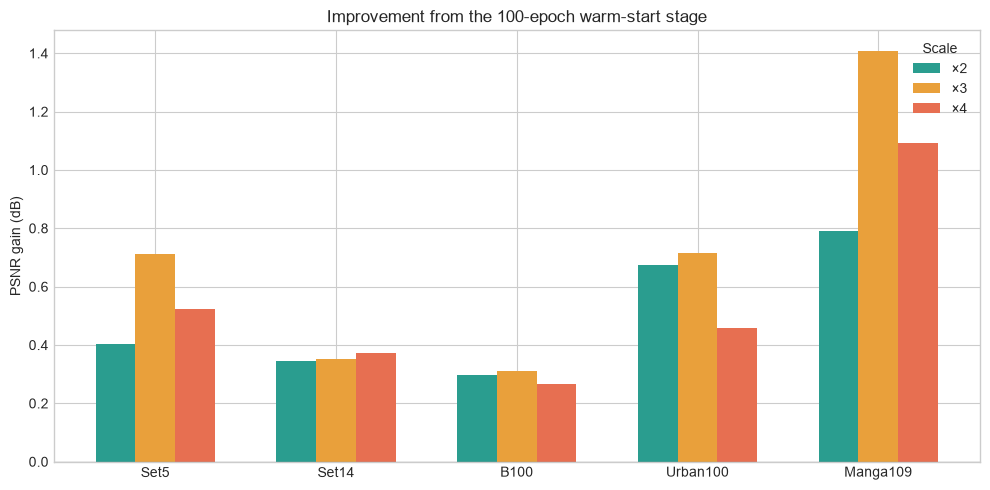

Saved report/images/warm_start_psnr_gain.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(DATASETS))
width = 0.22
colors = ("#2a9d8f", "#e9a03b", "#e76f51")

for index, (scale, color) in enumerate(zip(SCALES, colors)):
    gain = [
        metrics(scale, "warm_start", dataset)["stsn"]["psnr"]
        - metrics(scale, "stage_one", dataset)["stsn"]["psnr"]
        for dataset in DATASETS
    ]
    ax.bar(x + (index - 1) * width, gain, width, label=f"×{scale}", color=color)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, DATASETS)
ax.set_ylabel("PSNR gain (dB)")
ax.set_title("Improvement from the 100-epoch warm-start stage")
ax.legend(title="Scale")
fig.tight_layout()
path = REPORT_IMAGES_DIR / "warm_start_psnr_gain.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {path.relative_to(PROJECT_ROOT)}")

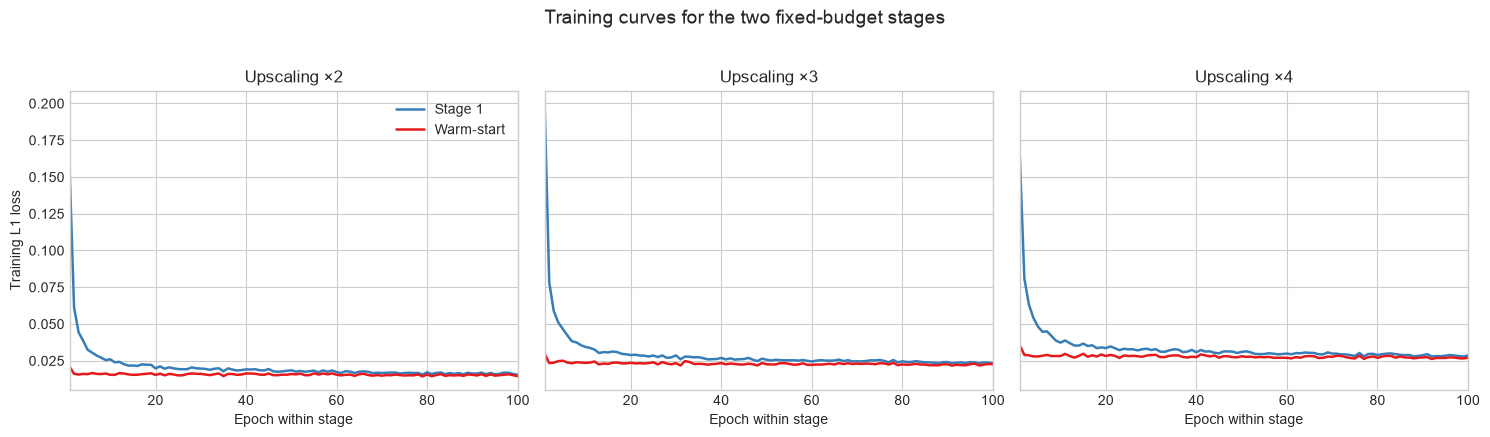

Saved report/images/training_loss_curves.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, scale in zip(axes, SCALES):
    for stage, label, color in (
        ("x" + str(scale), "Stage 1", "#377eb8"),
        ("warm_start/x" + str(scale), "Warm-start", "#e41a1c"),
    ):
        with (OUTPUTS_DIR / stage / "training_history.json").open(
            encoding="utf-8"
        ) as handle:
            history = json.load(handle)["history"]
        epochs = [row["epoch"] for row in history]
        losses = [row["train_l1"] for row in history]
        ax.plot(epochs, losses, label=label, color=color, linewidth=1.8)
    ax.set_title(f"Upscaling ×{scale}")
    ax.set_xlabel("Epoch within stage")
    ax.set_xlim(1, 100)

axes[0].set_ylabel("Training L1 loss")
axes[0].legend()
fig.suptitle("Training curves for the two fixed-budget stages", y=1.03, fontsize=14)
fig.tight_layout()
path = REPORT_IMAGES_DIR / "training_loss_curves.png"
fig.savefig(path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {path.relative_to(PROJECT_ROOT)}")